[주제 1] 수식 구조에 따른 마이크로 연산 오버헤드 & 클래스 불균형 민감도
 ├ 다항식 기반 Gini 계산 시간 (500만 건)     : 0.070395 초
 ├ 초월함수(Log2) 기반 Entropy 계산 시간      : 0.333093 초
 ├ └ 진단: Entropy가 Gini 대비 약 373.2%의 추가 연산 비용 발생.
 ├ 불균형 환경 내 Gini 트리의 총 노드 생성 개수 : 97개
 ├ 불균형 환경 내 Entropy 트리의 총 노드 생성 개수: 99개
 └ └ 진단: Entropy의 높은 비선형성 기울기가 미량의 소수 샘플 분류에 집착하여 과분할을 유도함.

[주제 3] CART 가중합산 목적함수에 따른 자식 노드 불순도 역전 추적
 🚨 역전 노드 발견 (Node ID: 0) -> 부모 노드 Gini: 0.1879
   ├ 왼쪽 자식 Gini: 0.3100 (샘플 수: 73)
   └ 오른쪽 자식 Gini: 0.0943 (샘플 수: 927)
 🚨 역전 노드 발견 (Node ID: 1) -> 부모 노드 Gini: 0.3100
   ├ 왼쪽 자식 Gini: 0.4885 (샘플 수: 33)
   └ 오른쪽 자식 Gini: 0.0000 (샘플 수: 40)
 🚨 역전 노드 발견 (Node ID: 4) -> 부모 노드 Gini: 0.2907
   ├ 왼쪽 자식 Gini: 0.1327 (샘플 수: 14)
   └ 오른쪽 자식 Gini: 0.4444 (샘플 수: 3)
 🚨 역전 노드 발견 (Node ID: 12) -> 부모 노드 Gini: 0.0943
   ├ 왼쪽 자식 Gini: 0.0504 (샘플 수: 850)
   └ 오른쪽 자식 Gini: 0.4291 (샘플 수: 77)
 🚨 역전 노드 발견 (Node ID: 15) -> 부모 노드 Gini: 0.0482
   ├ 왼쪽 자식 Gini: 0.0371 (샘플 수: 794)
   └ 오른쪽 자식 Gini: 0.1944 (샘플 수: 55)
 🚨 역전 노드 발견 (Node ID: 16) -> 부모 노드 G

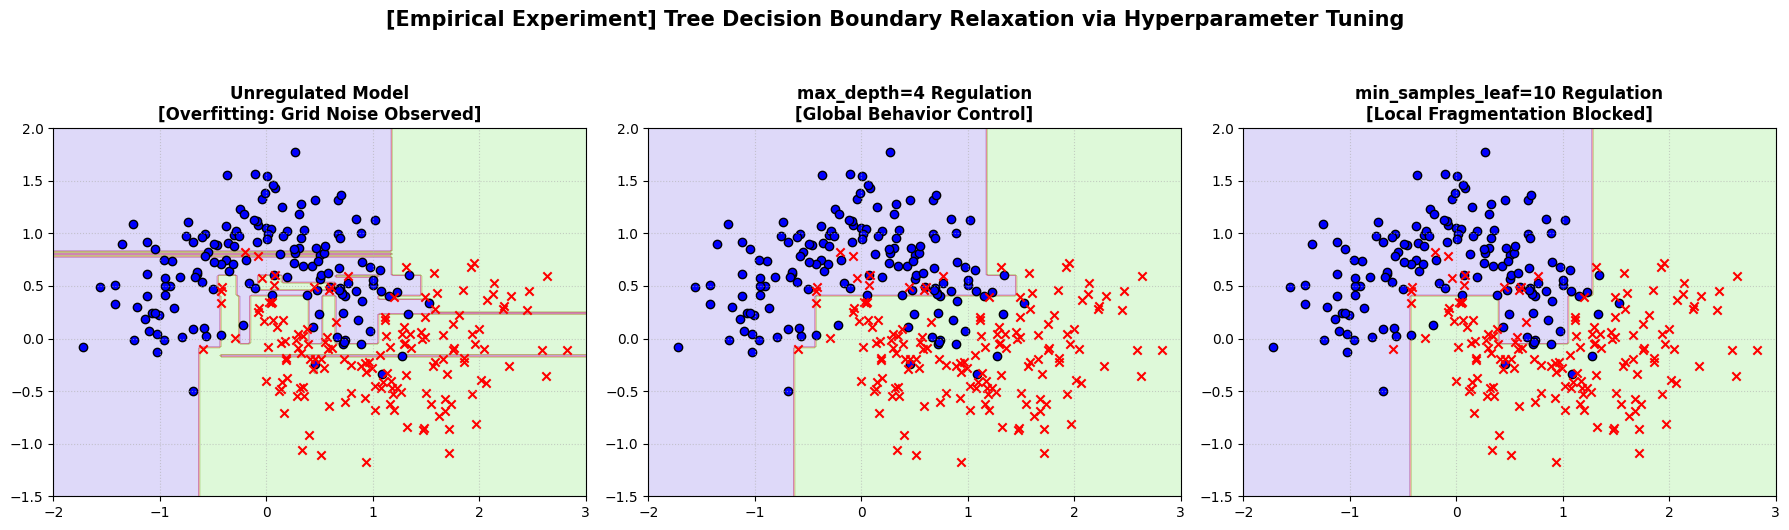

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.tree import DecisionTreeClassifier

# 글로벌 시드 고정 (실험 재현성 보장)
np.random.seed(42)

def benchmark_purity_and_imbalance():
    """ [주제 1] Gini vs Entropy: 초월함수 로그 연산 비용 및 불균형 민감도 실측 """
    print("=" * 75)
    print("[주제 1] 수식 구조에 따른 마이크로 연산 오버헤드 & 클래스 불균형 민감도")
    print("=" * 75)

    # 1. 하드웨어 관점의 연산 스트레스 테스트 (500만 건 부동소수점 배열)
    p = np.random.uniform(1e-5, 1-1e-5, size=5000000)

    start = time.time()
    gini_val = 1 - (p**2 + (1-p)**2)
    time_gini = time.time() - start
    print(f" ├ 다항식 기반 Gini 계산 시간 (500만 건)     : {time_gini:.6f} 초")

    start = time.time()
    entropy_val = -(p * np.log2(p) + (1-p) * np.log2(1-p))
    time_entropy = time.time() - start
    print(f" ├ 초월함수(Log2) 기반 Entropy 계산 시간      : {time_entropy:.6f} 초")
    print(f" ├ └ 진단: Entropy가 Gini 대비 약 {((time_entropy - time_gini)/time_gini)*100:.1f}%의 추가 연산 비용 발생.")

    # 2. 극단적 클래스 불균형(99:1) 환경에서의 트리 노드 과분할 성향 측정
    X_imb, y_imb = make_classification(n_samples=5000, n_features=10, weights=[0.99, 0.01], random_state=42)

    clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42).fit(X_imb, y_imb)
    clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42).fit(X_imb, y_imb)

    print(f" ├ 불균형 환경 내 Gini 트리의 총 노드 생성 개수 : {clf_gini.tree_.node_count}개")
    print(f" ├ 불균형 환경 내 Entropy 트리의 총 노드 생성 개수: {clf_entropy.tree_.node_count}개")
    print(f" └ └ 진단: Entropy의 높은 비선형성 기울기가 미량의 소수 샘플 분류에 집착하여 과분할을 유도함.")


def visualize_regulation_boundaries():
    """ [주제 2] 하이퍼파라미터 규제 제어에 따른 결정 경계(Contour) 시각화 """

    print("=" * 75)
    print("[주제 2] 하이퍼파라미터 규제 제어에 따른 결정 경계(Contour) 시각화")
    print("=" * 75)
    X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    scenarios = [
        {"model": DecisionTreeClassifier(random_state=42), "title": "Unregulated Model\n[Overfitting: Grid Noise Observed]"},
        {"model": DecisionTreeClassifier(max_depth=4, random_state=42), "title": "max_depth=4 Regulation\n[Global Behavior Control]"},
        {"model": DecisionTreeClassifier(min_samples_leaf=10, random_state=42), "title": "min_samples_leaf=10 Regulation\n[Local Fragmentation Blocked]"}
    ]

    x0s = np.linspace(-2.0, 3.0, 200)
    x1s = np.linspace(-1.5, 2.0, 200)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_map = np.c_[x0.ravel(), x1.ravel()]

    for idx, sc in enumerate(scenarios):
        ax = axes[idx]
        clf = sc["model"]
        clf.fit(X, y)

        y_pred = clf.predict(X_map).reshape(x0.shape)
        ax.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.15)

        ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', edgecolors='k')
        ax.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='x')
        ax.set_title(sc["title"], fontsize=12, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle("[Empirical Experiment] Tree Decision Boundary Relaxation via Hyperparameter Tuning", fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


def track_purity_inversion():
    """ [주제 3] CART 목적함수 우회: 자식 노드의 불순도 역전(상승) 현상 실측 """
    print("\n" + "=" * 75)
    print("[주제 3] CART 가중합산 목적함수에 따른 자식 노드 불순도 역전 추적")
    print("=" * 75)

    X_inv, y_inv = make_classification(n_samples=1000, n_features=5, weights=[0.90, 0.10], random_state=42)
    clf = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_inv, y_inv)

    tree = clf.tree_
    inversion_count = 0

    for i in range(tree.node_count):
        left = tree.children_left[i]
        right = tree.children_right[i]

        if left != -1: # 내부 분할 노드만 탐색
            p_gini = tree.impurity[i]
            l_gini = tree.impurity[left]
            r_gini = tree.impurity[right]

            if l_gini > p_gini or r_gini > p_gini:
                inversion_count += 1
                print(f" 🚨 역전 노드 발견 (Node ID: {i}) -> 부모 노드 Gini: {p_gini:.4f}")
                print(f"   ├ 왼쪽 자식 Gini: {l_gini:.4f} (샘플 수: {tree.n_node_samples[left]})")
                print(f"   └ 오른쪽 자식 Gini: {r_gini:.4f} (샘플 수: {tree.n_node_samples[right]})")

    print(f" └ 결론: 전체 시스템의 정보 이득 극대화를 위한 국소 역전 노드 총 {inversion_count}건 검출.")

if __name__ == "__main__":
    benchmark_purity_and_imbalance()
    track_purity_inversion()
    visualize_regulation_boundaries()